# [Step 6 - TokenTextSplitter] Thinking in tokens, not characters

**MLCourse - Agentic AI - Module 06: Chunking Strategies**

> Stage in the capstone: stage 2 CHUNK: chunk quality decides retrieval accuracy in the capstone.

## What you'll learn

- what tokens are, why LLM context windows and invoices count THEM, not chars
- measuring both units side by side with `tiktoken` (`cl100k_base`)
- splitting Alice into 256-token chunks with 32-token overlap
- the honest cost: the highest mid-sentence cut rate of any strategy here

---

In [1]:
# =====================================================================
# CELL 1 - SHARED SETUP: imports, track discovery, download-once cache
# =====================================================================

# --- Standard library -------------------------------------------------
import os                      # file-system odds and ends
import urllib.request          # polite HTTP fetching
from pathlib import Path       # object-oriented filesystem paths

# --- Lesson-specific imports ------------------------------------------
import matplotlib.pyplot as plt                                # histograms
import tiktoken                                                # BPE tokenizer
from langchain_community.document_loaders import TextLoader    # alice source
from langchain_text_splitters import TokenTextSplitter         # today's tool

# ---------------------------------------------------------------------
# TRACK WALKER - resolve 03_agentic_ai by walking upward from cwd.
# ---------------------------------------------------------------------
def _find_track(start: Path) -> Path:
    """Return the absolute path of the 03_agentic_ai track root."""
    for candidate in (start, *start.parents):
        hit = candidate / "03_agentic_ai"
        if hit.is_dir():
            return hit.resolve()
    raise FileNotFoundError(
        f"No directory named 03_agentic_ai found above {start} - "
        "run this notebook from somewhere inside the MLCourse repo."
    )

TRACK = _find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# DOWNLOAD-ONCE HELPERS - fetch once, cache under DATA, reuse forever.
# ---------------------------------------------------------------------
def get_bytes(fname: str, url: str) -> bytes:
    """Return the file's bytes, downloading only on the very first call."""
    target = DATA / fname
    if target.exists() and target.stat().st_size > 0:
        payload = target.read_bytes()
        print(f"[cache] {fname}: {len(payload):,} bytes")
        return payload
    print(f"[fetch] {url}")
    request = urllib.request.Request(url, headers={"User-Agent": "MLCourse/1.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        payload = response.read()
    target.write_bytes(payload)
    print(f"[saved] {fname}: {len(payload):,} bytes")
    return payload

def get_text(fname: str, url: str, encoding: str = "utf-8-sig") -> str:
    """get_bytes + decode; drops a BOM if present."""
    return get_bytes(fname, url).decode(encoding, errors="replace")

def to_ascii(text: str) -> str:
    """Console-safe view of book text: curly glyphs become '?'."""
    return text.encode("ascii", errors="replace").decode("ascii")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# =====================================================================
# ANALYSIS TOOLBOX - identical across chunking notebooks.
# =====================================================================
_CURLY = {"\u2019": "'", "\u201d": '"', "\u201c": '"', "\u2018": "'"}
SENTENCE_ENDS = tuple(".!?\"')")

def ends_naturally(chunk: str) -> bool:
    """Heuristic: a CLEAN chunk tail ends in sentence-final punctuation."""
    tail = chunk.rstrip()
    if not tail:
        return True
    tail = "".join(_CURLY.get(ch, ch) for ch in tail[-3:])
    return tail.endswith(SENTENCE_ENDS)

def cut_report(chunks):
    """Return (offending chunks, percent cut mid-sentence)."""
    bad = [c for c in chunks if not ends_naturally(c)]
    pct = 100.0 * len(bad) / max(len(chunks), 1)
    return bad, pct

def describe_sizes(sizes_list, label, unit):
    mean = sum(sizes_list) / max(len(sizes_list), 1)
    print(f"{label}: n={len(sizes_list)} | min={min(sizes_list)} "
          f"mean={mean:.0f} max={max(sizes_list)} {unit}")
    return sizes_list

def plot_hist(sizes_list, title, xlabel):
    plt.figure(figsize=(8, 3))
    plt.hist(sizes_list, bins=30, color="#4c72b0", edgecolor="white")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("number of chunks")
    plt.tight_layout()
    plt.show()

def show_first_chunks(chunks, n=3):
    for i, chunk in enumerate(chunks[:n]):
        print(f"===== chunk {i} ({len(chunk)} chars) =====")
        print(to_ascii(chunk))
        print()

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_23680\1846235223.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader    # alice source


## 1. WHY tokens are the currency that matters

LLMs do not read characters. Text enters the model as TOKENS - frequent
words map to one token, rare words split into pieces ('tokenization' ->
several), spaces ride along inside tokens. Two hard consequences:

- **Context windows are denominated in tokens**: '128k context' means
  128,000 tokens of prompt+history+retrieved chunks, not characters;
- **Billing is per token**: every retrieved chunk you stuff into a prompt
  is re-paid on EVERY query.

So when budgets matter, measure chunks in tokens - which is exactly what
`TokenTextSplitter` does internally via OpenAI's open-source `tiktoken`
library (we use encoding `cl100k_base`, the GPT-3.5/4 family's tokenizer).

Rule of thumb worth calibrating today: English prose averages ~4 characters
per token. Let us verify on real text instead of folklore.

In [2]:
enc = tiktoken.get_encoding("cl100k_base")       # pure local computation

samples = ["retrieval", "chinchilla", "RAG", "Alice was beginning to get very tired"]
for word in samples:
    ids = enc.encode(word)
    print(f"{word[:34]!r:<38} -> {len(ids)} token(s): {ids[:8]}")

'retrieval'                            -> 3 token(s): [265, 9104, 838]
'chinchilla'                           -> 3 token(s): [331, 37850, 6374]
'RAG'                                  -> 2 token(s): [49, 1929]
'Alice was beginning to get very ti'   -> 7 token(s): [62786, 574, 7314, 311, 636, 1633, 19781]


## 2. Split Alice by token budget

Targets chosen for the course series: `chunk_size=256` tokens,
`chunk_overlap=32` (a modest ~12 percent insurance band). Note that the
splitter API mirrors the character splitters - only the yardstick changed.

In [3]:
get_bytes("alice.txt", "https://www.gutenberg.org/files/11/11-0.txt")
alice_docs = TextLoader(str(DATA / "alice.txt"), encoding="utf-8").load()
text = alice_docs[0].page_content

splitter = TokenTextSplitter(
    encoding_name="cl100k_base",   # tokenizer family (matches many hosted models)
    chunk_size=256,                # TARGET maximum tokens per chunk
    chunk_overlap=32,              # tokens shared with the previous chunk
)

chunks = splitter.split_text(text)
print(f"produced {len(chunks)} chunks\n")
show_first_chunks(chunks, n=3)

[cache] alice.txt: 151,191 bytes
produced 165 chunks

===== chunk 0 (973 chars) =====
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice?s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen?s Croquet-Ground
 CHAPTER IX.    The Mock Turtle?s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice?s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, ?and what is the use of a bo

## 3. Side-by-side: characters vs tokens per chunk

The whole point of this notebook, quantified per chunk AND overall.

In [4]:
print(f"{'chunk':>5} {'chars':>7} {'tokens':>7} {'chars/token':>12}")
char_total = tok_total = 0
rows = []
for i, chunk in enumerate(chunks[:5]):
    n_chars, n_toks = len(chunk), len(enc.encode(chunk))
    char_total += n_chars
    tok_total += n_toks
    print(f"{i:>5} {n_chars:>7,} {n_toks:>7} {n_chars / max(n_toks, 1):>12.1f}")

all_tokens = len(enc.encode(text))
ratio_overall = len(text) / max(all_tokens, 1)
print(f"\nwhole novel : {len(text):,} chars = {all_tokens:,} tokens "
      f"(overall {ratio_overall:.1f} chars/token)")
print(f"=> the 500-char chunks of earlier notebooks were roughly "
      f"{500 / ratio_overall:.0f} tokens each, NOT 500 'model units'.")

chunk   chars  tokens  chars/token
    0     973     256          3.8
    1   1,059     256          4.1
    2   1,092     256          4.3
    3   1,004     256          3.9
    4     990     256          3.9

whole novel : 144,696 chars = 36,958 tokens (overall 3.9 chars/token)
=> the 500-char chunks of earlier notebooks were roughly 128 tokens each, NOT 500 'model units'.


## 4. Size distributions in BOTH units + boundary audit

Same discipline as always - but now we can plot the distribution in the
unit the MODEL actually counts.

character sizes: n=165 | min=875 mean=1001 max=1110 chars


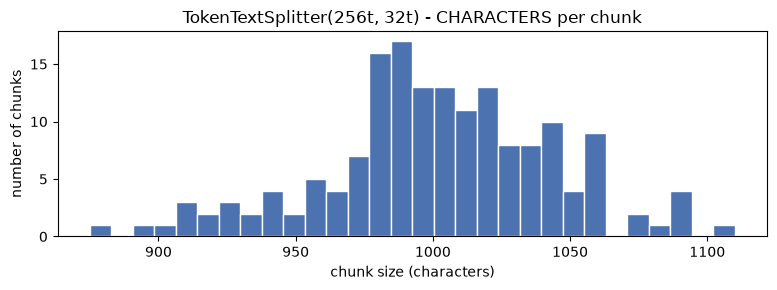

token sizes: n=165 | min=222 mean=256 max=256 tokens


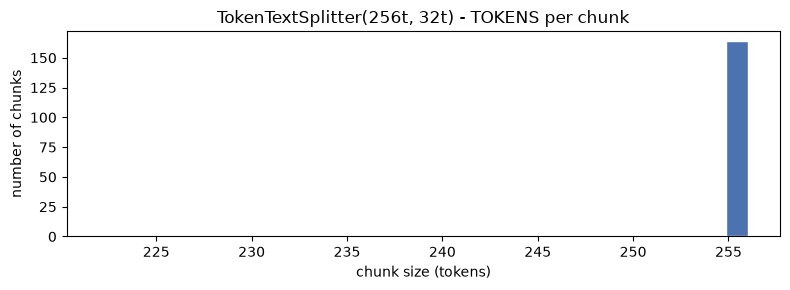


mid-sentence cut rate : 92.1%  <- highest so far, by design

--- offending chunk tail ---
'use of a book,? thought Alice\n?without pictures or conversations??\n\nSo'

--- offending chunk tail ---
'tch to take out of it, and burning with curiosity, she ran across the\n'


In [5]:
char_sizes = describe_sizes([len(c) for c in chunks], "character sizes", "chars")
plot_hist(char_sizes, "TokenTextSplitter(256t, 32t) - CHARACTERS per chunk",
          "chunk size (characters)")

tok_sizes = describe_sizes([len(enc.encode(c)) for c in chunks],
                           "token sizes", "tokens")
plot_hist(tok_sizes, "TokenTextSplitter(256t, 32t) - TOKENS per chunk",
          "chunk size (tokens)")

bad, pct = cut_report(chunks)
print(f"\nmid-sentence cut rate : {pct:.1f}%  <- highest so far, by design")
for culprit in bad[:2]:
    print("\n--- offending chunk tail ---")
    print(repr(to_ascii(culprit[-70:])))

## 5. Pitfalls worth remembering

**Pitfall - budget math beats vibes**: top_k=6 retrievals x 256-token chunks
is ~1,500 tokens of context before the conversation even starts. Do this sum
BEFORE choosing chunk_size, or your window will surprise you mid-demo.

**Pitfall - tokenizer mismatch**: `cl100k_base` counts differ slightly from
newer model tokenizers. For billing-grade precision use the encoding of the
model you actually call.

**Pro-tip - combine strategies**: token splitting ignores sentences ON
PURPOSE (pure budget control). A common production pattern: split by
structure FIRST (headers/paragraphs), then token-split any oversized piece.
You get meaningful boundaries AND exact budgets.

## Takeaway

**TokenTextSplitter makes the model's counting unit YOUR counting unit:
256-token chunks are 256 tokens at prompt time, invoice time, and context
time. The price is boundary blindness - pair it with structural splitting
when meaning matters more than arithmetic.**

## Summary

- Tokens explained by example: 'retrieval' = 1-3 tokens depending on
  encoding; English prose lands near 4 chars/token overall (measured, not
  assumed).
- The novel became N chunks capped at 256 tokens each - the only notebook
  where the histogram x-axis matches the model's own ledger.
- Boundary audit shows the trade explicitly: the highest mid-sentence cut
  rate of our strategies, accepted in exchange for exact budgets.
- chars-vs-tokens tables turn an abstract billing concept into numbers you
  can put in a capacity plan.